In [1]:
import sys
import os

# Get the current working directory
cwd = os.getcwd()
print(f"Current Working Directory: {cwd}")

# Define the path to the 'mapelite' folder
# We assume the notebook is running from the root 'Quality-Diversity-...' folder
mapelite_path = os.path.join(cwd, 'mapelite')

# Add it to the system path so Python can find config.py, utils.py, etc.
if mapelite_path not in sys.path:
    sys.path.append(mapelite_path)
    print(f"Added '{mapelite_path}' to sys.path")

Current Working Directory: d:\dev\Quality-Diversity-for-Racing-Track-Design
Added 'd:\dev\Quality-Diversity-for-Racing-Track-Design\mapelite' to sys.path


In [2]:
from mapelite.logging_config import setup_logging
from mapelite.config import LOG_DIR, LOG_CONSOLE_LEVEL, LOG_FILE_LEVEL
log_file = setup_logging(
    log_dir=LOG_DIR,
    console_level=LOG_CONSOLE_LEVEL,   # INFO  → shown on console
    file_level=LOG_FILE_LEVEL,         # DEBUG → written to log file
    log_filename=f"novelty_search"
)
print(f"Log file: {log_file}")
from mapelite.logging_config import get_logger
log = get_logger(__name__)


09:05:07 [INFO] Logging initialised | console_level=INFO file_level=DEBUG log_file=logs\novelty_search_20260525_110507.log


Log file: logs\novelty_search_20260525_110507.log


In [3]:
import numpy as np
import random
import os

from ribs.archives import ProximityArchive
from ribs.schedulers import Scheduler

from mapelite.emitter import CustomEmitter
from mapelite.qd_runner import QDRunner

In [4]:
from mapelite.config import (
    SOLUTION_DIM,
    BATCH_SIZE,
    NS_DIR,
    BUFFER_FILENAME,
    CHECKPOINT_DIR,
    ELITES_FILENAME,
    HEATMAP_DIR,
    GRIDPLOT_DIR,
    ITERATIONS,
    NS_KNN,
    EMBEDDING_MODEL_PATH,
    PRECOMPILED_EMBEDDINGS_PATH,
    DEFAULT_ARCHIVE_THRESHOLD
)

# --- Novelty Search specific config ---
checkpoint_dir = os.path.join(NS_DIR, CHECKPOINT_DIR)
heatmap_dir = os.path.join(NS_DIR, HEATMAP_DIR)
gridplot_dir = os.path.join(NS_DIR, GRIDPLOT_DIR)
buffer_path = os.path.join(NS_DIR, BUFFER_FILENAME)

SEED = 67
ELITES_OUTPUT = os.path.join(NS_DIR, ELITES_FILENAME)
ALGORITHM_LABEL = "Novelty Search (ProximityArchive + local competition)"

random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)

In [5]:
# --- Calculate a good novelty threshold from the embedding dataset ---
# Fits k-NN (same k as the archive) on the pre-existing embeddings and
# reports percentile distances so you can pick an informed threshold.

from sklearn.neighbors import NearestNeighbors

_raw = np.load(PRECOMPILED_EMBEDDINGS_PATH)["embeddings"]

_k = 15  # same as archive k_neighbors
_nbrs = NearestNeighbors(n_neighbors=_k + 1).fit(_raw)
_dists, _ = _nbrs.kneighbors(_raw)
_knn_mean_per_point = _dists[:, 1:].mean(axis=1)  # exclude self (col 0)

print(f"Dataset: {len(_raw)} embeddings  |  k={_k}  |  measure dim: {_raw.shape[1]}")
print(f"  Mean k-NN dist : {_knn_mean_per_point.mean():.4f}")
for _p in (5.0, 10.0, 25.0, 50.0, 75.0, 90.0, 95.0, 98.0, 99.0, 99.5, 99.9):
    print(f"  {_p:5.1f}th percentile: {np.percentile(_knn_mean_per_point, _p):.4f}")

log.info(f"ARCHIVE_THRESHOLD set to {DEFAULT_ARCHIVE_THRESHOLD:.4f}  (manually set in config.py)")


09:05:56 [INFO] ARCHIVE_THRESHOLD set to 6.3000  (manually set in config.py)


Dataset: 19183 embeddings  |  k=15  |  measure dim: 32
  Mean k-NN dist : 4.8653
    5.0th percentile: 3.5066
   10.0th percentile: 3.9454
   25.0th percentile: 4.4938
   50.0th percentile: 4.9751
   75.0th percentile: 5.3655
   90.0th percentile: 5.6826
   95.0th percentile: 5.8691
   98.0th percentile: 6.0814
   99.0th percentile: 6.2212
   99.5th percentile: 6.3804
   99.9th percentile: 6.7219


In [6]:
# --- Initialize directories ---
os.makedirs(NS_DIR, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(heatmap_dir, exist_ok=True)
os.makedirs(gridplot_dir, exist_ok=True)

In [ ]:
# print cuda device if available
import torch
if torch.cuda.is_available():
    log.info(f"CUDA device available: {torch.cuda.get_device_name(0)}")
else:
    log.info("No CUDA device available, using CPU.")

In [7]:
# --------------------------------------------------------------
# Resume from latest checkpoint if available,
# otherwise build archive from scratch
# --------------------------------------------------------------
state = QDRunner.get_state_from_checkpoint(checkpoint_dir)

_embedding_dim = np.load(PRECOMPILED_EMBEDDINGS_PATH)["embeddings"].shape[1]

if state["scheduler"] is not None:
    runner = QDRunner.load_state(
        state,
        pretrained_model_path=EMBEDDING_MODEL_PATH,
        checkpoint_dir=checkpoint_dir,
        heatmap_dir=heatmap_dir,
        gridplot_dir=gridplot_dir,
        buffer_path=buffer_path,
        seed=SEED,
    )
else:
    archive = ProximityArchive(
        solution_dim=SOLUTION_DIM,
        measure_dim=_embedding_dim,
        k_neighbors=NS_KNN,
        novelty_threshold=DEFAULT_ARCHIVE_THRESHOLD,
        seed=SEED,
        local_competition=True
    )
    emitter = CustomEmitter(
        archive,
        solution_dim=SOLUTION_DIM,
        batch_size=BATCH_SIZE,
        bounds=None,
        seed=SEED,
    )

    scheduler = Scheduler(archive, [emitter])

    runner = QDRunner(
        scheduler=scheduler,
        archive=archive,
        pretrained_model_path=EMBEDDING_MODEL_PATH,
        checkpoint_dir=checkpoint_dir,
        heatmap_dir=heatmap_dir,
        gridplot_dir=gridplot_dir,
        buffer_path=buffer_path,
        finetune=True,
        seed=SEED,
    )


09:05:56 [INFO] No checkpoint found — starting fresh
09:05:56 [INFO] Buffer empty — starting fresh | path=data/ns/buffer.json
d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
09:06:18 [INFO] Retraining enabled: will finetune evaluator on elites every 150 iterations and recalculate measures for all archived elites.


Loading model from mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_circular_7.pth...
Model loaded with latent_dim=32


In [8]:
# print ribs version
import ribs
print(f"Ribs version: {ribs.__version__}")

Ribs version: 0.8.1


In [9]:
# Run main loop
global_best_score, global_best_id, stats = runner.run(
    total_iters=ITERATIONS,
    start_iter=state["start_iter"],
)

09:06:28 [INFO] Emitter.ask called | iteration=0
09:07:12 [INFO] Iteration complete | batch_best=10.00 global_best=10.00 global_best_id=0.4083858055777375 iteration=0 new_elites=10 substituted=0
09:07:12 [INFO] Archive stats | best=10.00 mean=5.67 size=10
09:07:12 [INFO] Stats updated | iteration=0 stats={'iteration': 0, 'Archive size': 10, 'iteration_best': 10.0, 'global_best_score': 10.0, 'global_best_id': 0.4083858055777375, 'new_elites': 10, 'substituted_elites': 0, 'qd_score': 56.75, 'acceptance_rate': 1.0, 'mean_pairwise_dist': 7.34788697523465, 'high_quality_coverage': 2, 'mean_knn_novelty': nan, 'fitness_novelty_corr': nan}
09:07:14 [INFO] Emitter.ask called | iteration=1
09:07:14 [WARNING] Error generating solution | error=API error 500: {"error":"Track with seed 1.5265942060000879 has self-intersection."} iteration=1
09:07:35 [WARNING] Unexpectedly lower objective in add() call — skipping bad replacements | indices=[5] new_objectives=[-1.e+09] old_objectives=[10.]
09:07:35 [I

[Fine-tune] Frozen encoder blocks: 2/5  (dilation 1–2).
  Frozen params  : 460,288  (16.3 %)
  Trainable params: 2,370,627  (83.7 %)
[Fine-tune] Differential LR — encoder: 1.0e-04, decoder: 1.0e-05


Overall Progress:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 1/80 [Train]:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1:
  Train — total: 8.5209 | recon: 8.5209 | kld: 51.6726
  Val   — total: 7.1275 | recon: 7.1275 | kld: 57.1730
  LR: 1.00e-04 (dec 1.00e-05)


...

Epoch 43:
  Train — total: 4.4711 | recon: 3.9841 | kld: 97.4027
  Val   — total: 7.1738 | recon: 6.6770 | kld: 99.3640
  LR: 1.00e-04 (dec 1.00e-05)


Epoch 44/80 [Train]:   0%|          | 0/3 [00:00<?, ?it/s]


Early stopping triggered at epoch 44
Restoring model to best validation loss from epoch 28: 6.6532


11:11:08 [INFO] Recalculating novelty threshold and remapping archive | new_threshold=6.184974849638839
11:11:08 [INFO] Elite novelty filter complete | collision_winners=20 novel_admitted=374 total_to_add=394
2026-05-25 13:11:12,867 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-05-25 13:11:12,932 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-05-25 13:11:12,934 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-05-25 13:11:12,934 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-05-25 13:11:12,936 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-05-25 13:11:12,937 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-05-25 13:11:12,938 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-05-25 13:11:12,9

KeyboardInterrupt: 

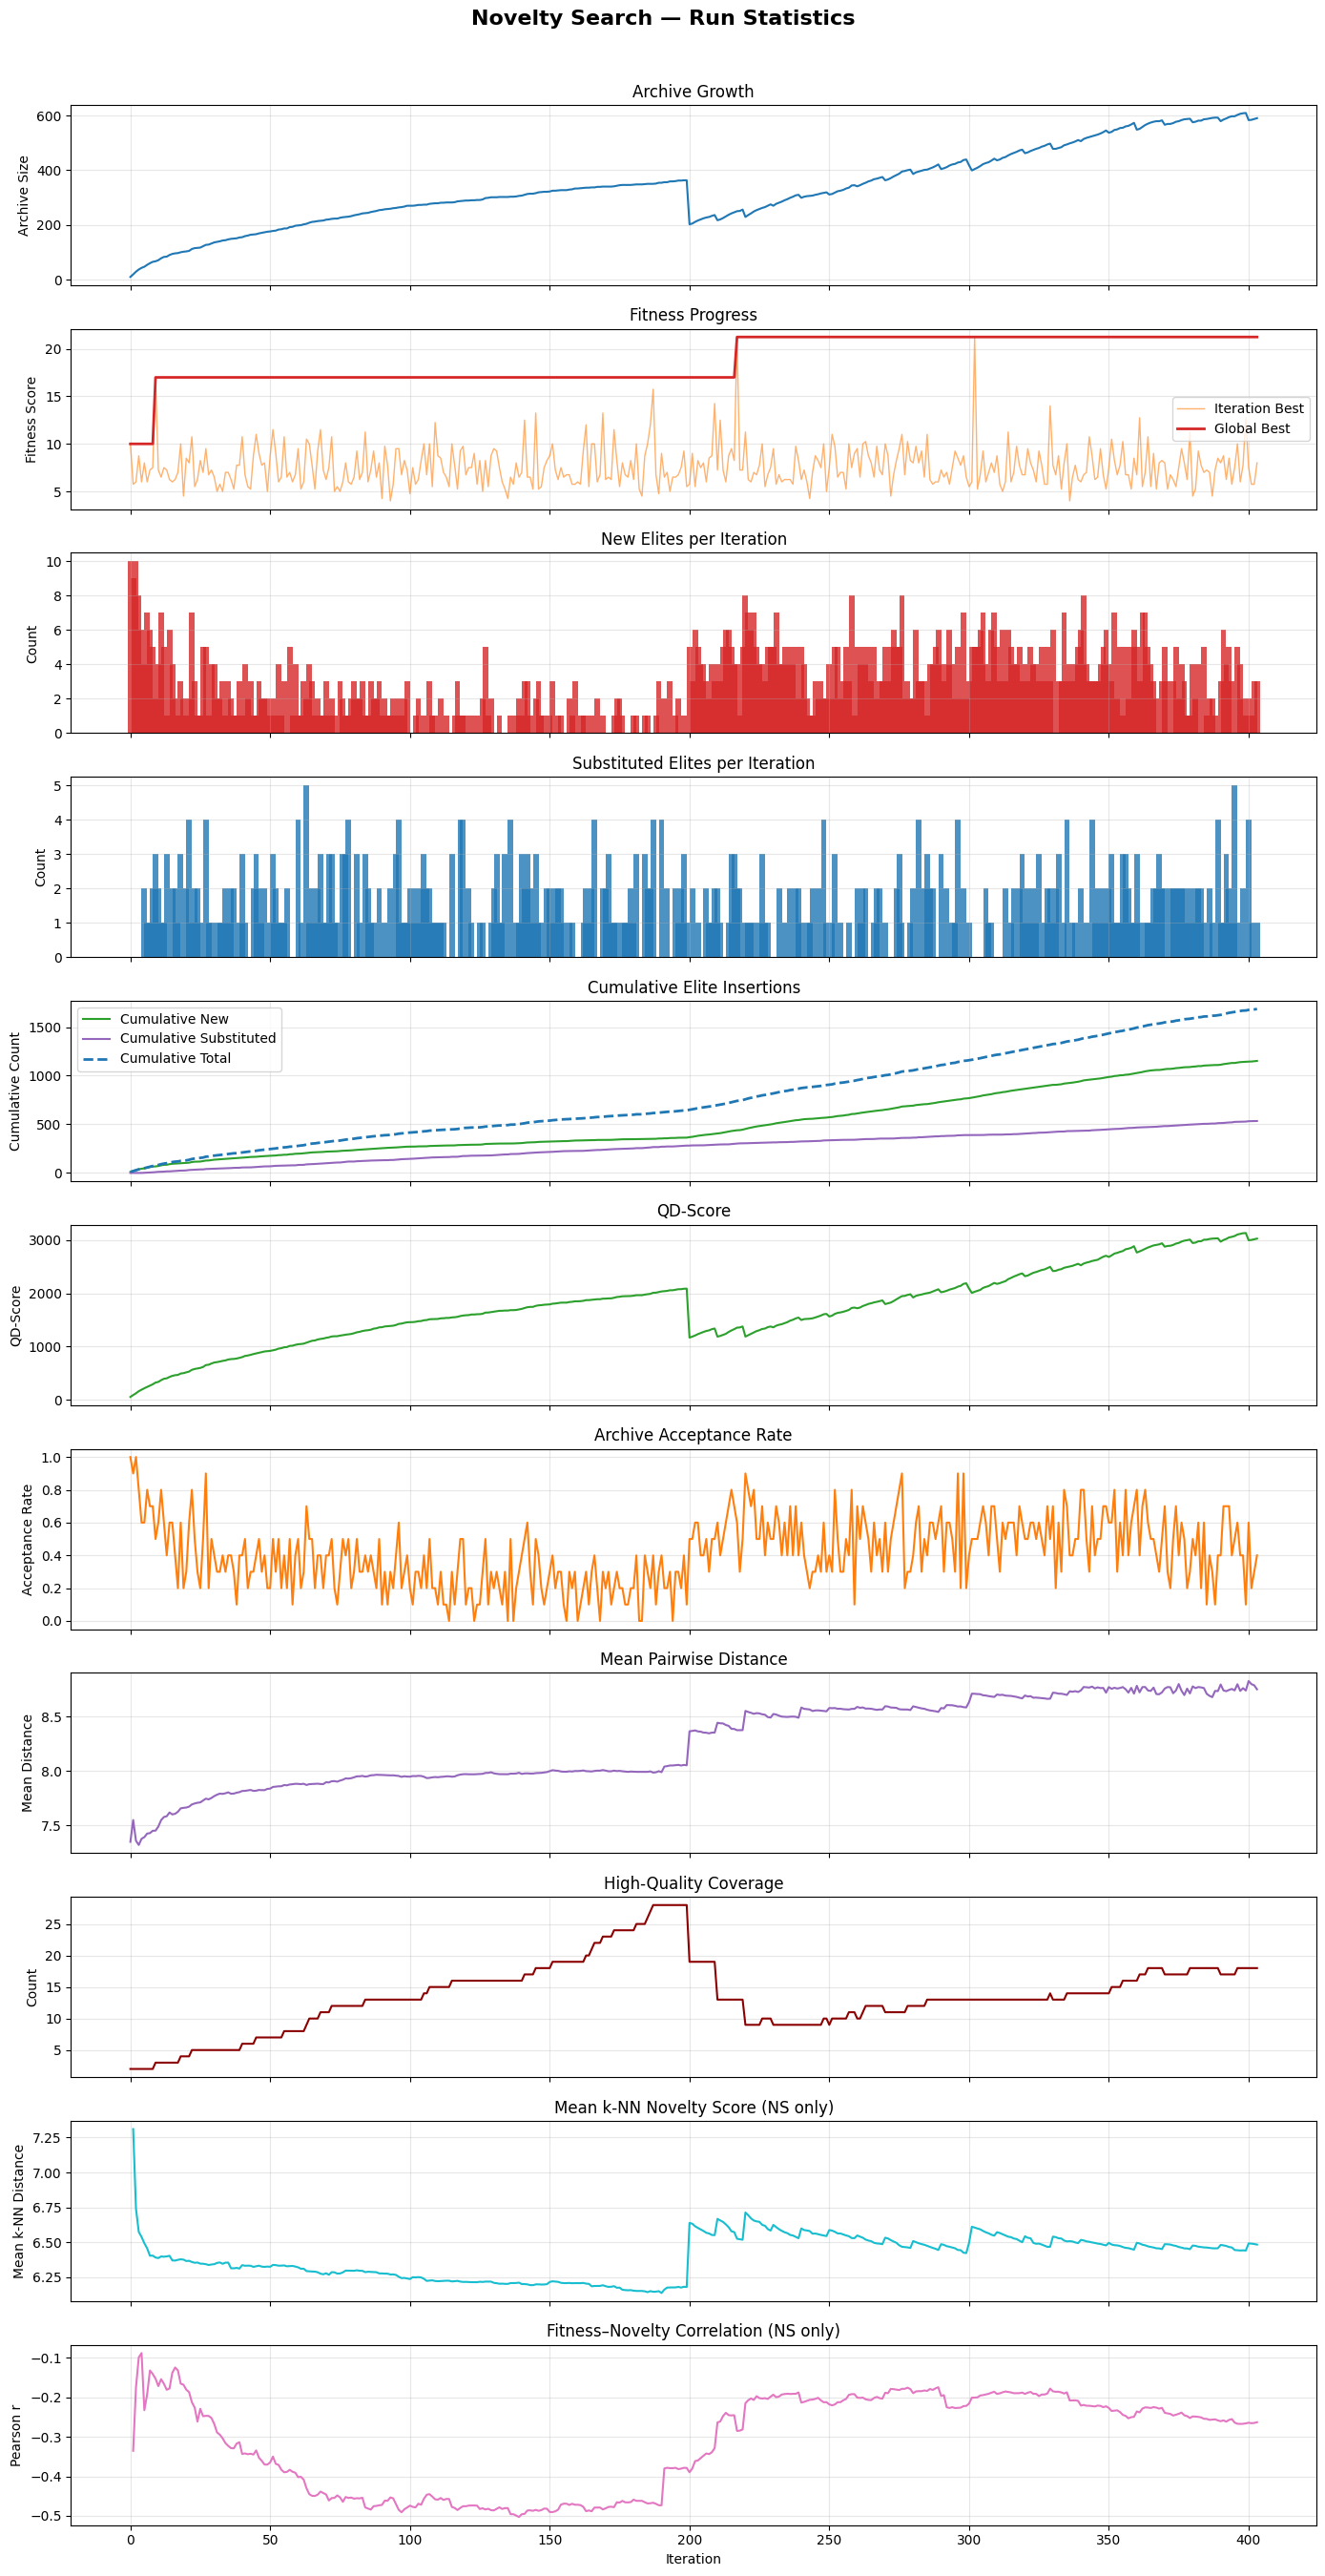

12:54:07 [INFO] Run summary | avg_new_per_iter=2.85 avg_sub_per_iter=1.32 final_archive_size=590 global_best_fitness=21.2500 title=Novelty Search total_iterations=404 total_new_elites=1152 total_substituted=534


In [10]:
runner.visualizer.plot_stats(title="Novelty Search", stats_dir=NS_DIR)

In [ ]:
runner.visualizer.export_elites(
    output_path=ELITES_OUTPUT,
    algorithm_label=ALGORITHM_LABEL,
    seed=SEED
)

15:00:18 [INFO] Elites exported | best_fitness=20.0000 best_id=711.2517724260751 count=537 file_kb=5913.3 path=data/ns/elites.json worst_fitness=1.0000
